In [1]:
from collections import defaultdict
import copy

class CSP:
    def __init__(self, variables, domains, neighbors):
        self.variables = variables
        self.domains = domains
        self.neighbors = neighbors

    def is_consistent(self, var, value, assignment):
        for neighbor in self.neighbors[var]:
            if neighbor in assignment and assignment[neighbor] == value:
                return False
        return True

    def forward_check(self, var, value, domains, assignment):
        new_domains = copy.deepcopy(domains)
        for neighbor in self.neighbors[var]:
            if neighbor not in assignment:
                if value in new_domains[neighbor]:
                    new_domains[neighbor].remove(value)
                if not new_domains[neighbor]:
                    return None
        return new_domains

    def select_unassigned_variable(self, assignment, domains):
        unassigned = [v for v in self.variables if v not in assignment]

        mrv = sorted(unassigned, key=lambda var: len(domains[var]))
        min_val = len(domains[mrv[0]])

        candidates = [v for v in mrv if len(domains[v]) == min_val]

        if len(candidates) == 1:
            return candidates[0]

        return max(candidates, key=lambda var: len(self.neighbors[var]))

    def backtrack(self, assignment, domains, step=0):
        if len(assignment) == len(self.variables):
            return assignment

        var = self.select_unassigned_variable(assignment, domains)

        for value in domains[var]:
            if self.is_consistent(var, value, assignment):
                print(f"Step {step}: Assign {var} = {value}")
                
                new_assignment = assignment.copy()
                new_assignment[var] = value

                new_domains = self.forward_check(var, value, domains, new_assignment)

                if new_domains is not None:
                    result = self.backtrack(new_assignment, new_domains, step + 1)
                    if result:
                        return result

        print(f"Backtrack on {var}")
        return None


variables = ['WA', 'NT', 'Q', 'SA', 'NSW', 'V', 'T']

domains = {
    'WA': ['Red', 'Green', 'Blue'],
    'NT': ['Red', 'Green', 'Blue'],
    'Q': ['Red', 'Green', 'Blue'],
    'SA': ['Red', 'Green', 'Blue'],
    'NSW': ['Red', 'Green', 'Blue'],
    'V': ['Red', 'Green', 'Blue'],
    'T': ['Red', 'Green', 'Blue']
}

neighbors = {
    'WA': ['NT', 'SA'],
    'NT': ['WA', 'SA', 'Q'],
    'Q': ['NT', 'SA', 'NSW'],
    'SA': ['WA', 'NT', 'Q', 'NSW', 'V'],
    'NSW': ['Q', 'SA', 'V'],
    'V': ['SA', 'NSW'],
    'T': []
}


csp = CSP(variables, domains, neighbors)

solution = csp.backtrack({}, domains)

print("\nFinal Solution:")
print(solution)

Step 0: Assign SA = Red
Step 1: Assign NT = Green
Step 2: Assign Q = Blue
Step 3: Assign NSW = Green
Step 4: Assign WA = Blue
Step 5: Assign V = Blue
Step 6: Assign T = Red

Final Solution:
{'SA': 'Red', 'NT': 'Green', 'Q': 'Blue', 'NSW': 'Green', 'WA': 'Blue', 'V': 'Blue', 'T': 'Red'}


In [3]:
%pip install networkx matplotlib

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



Animating CSP solving...



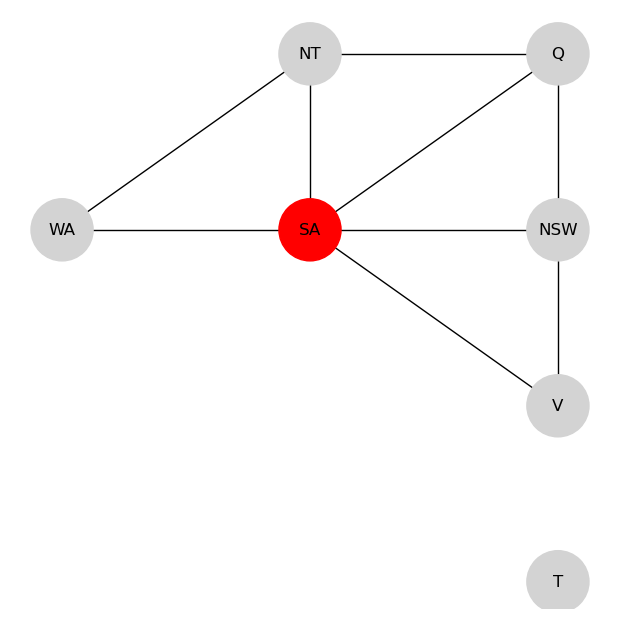

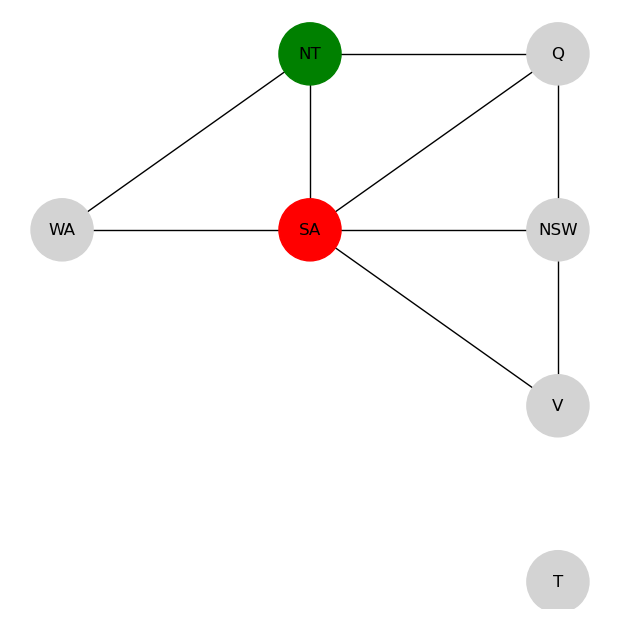

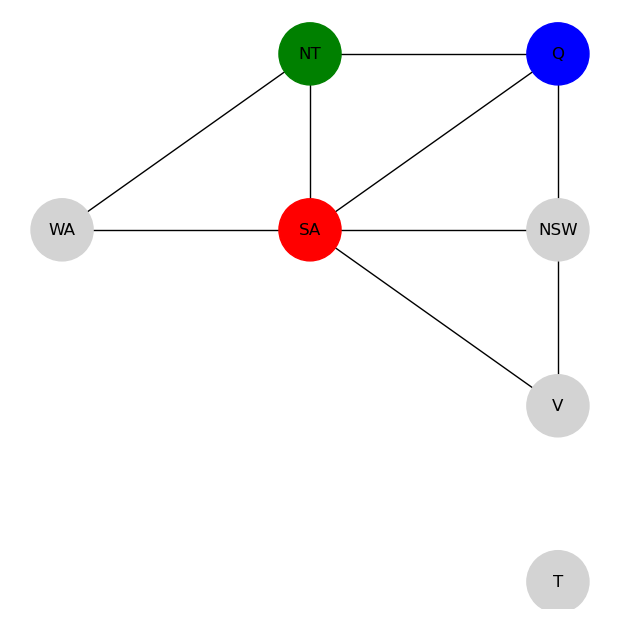

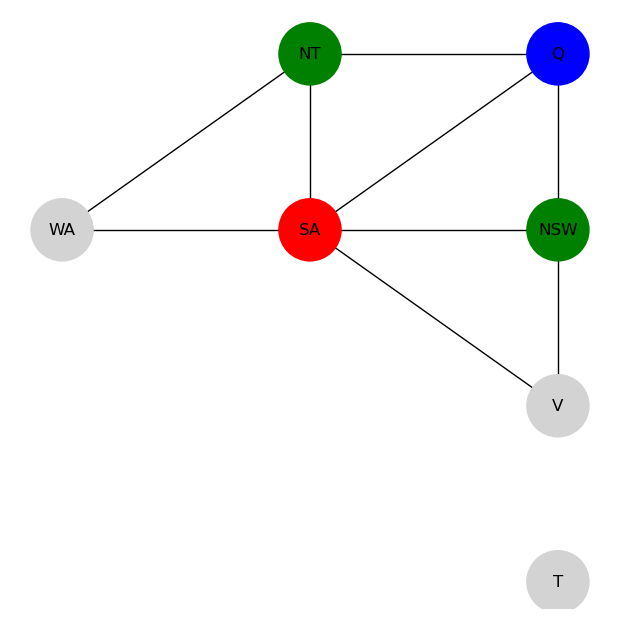

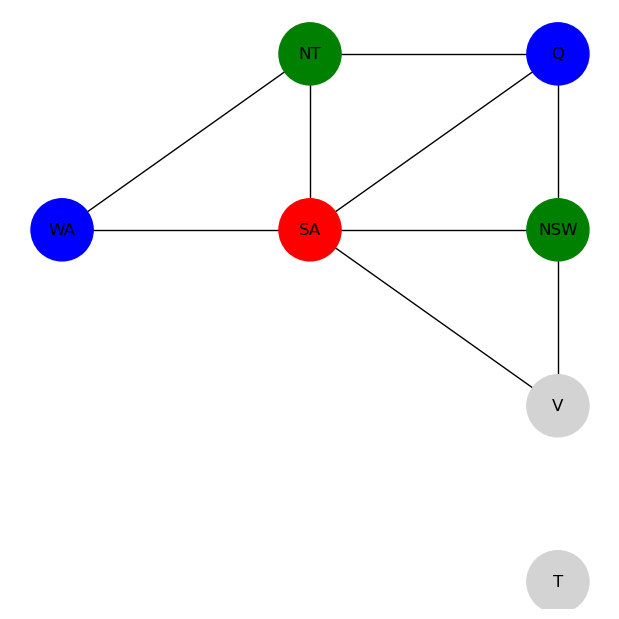

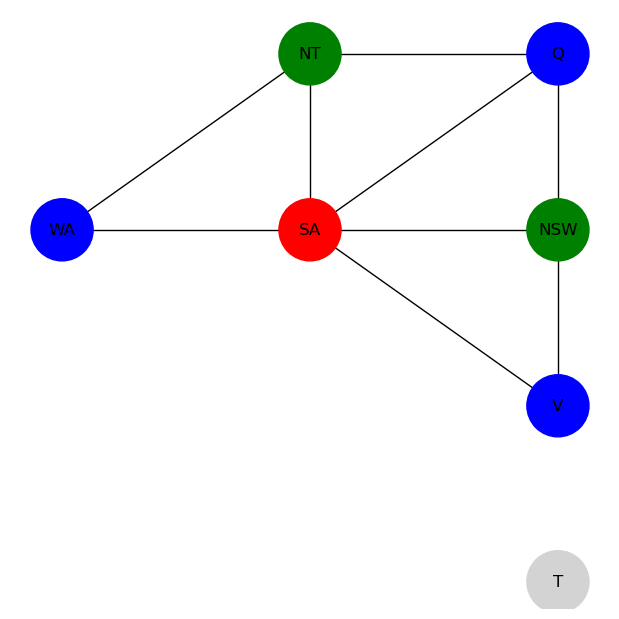

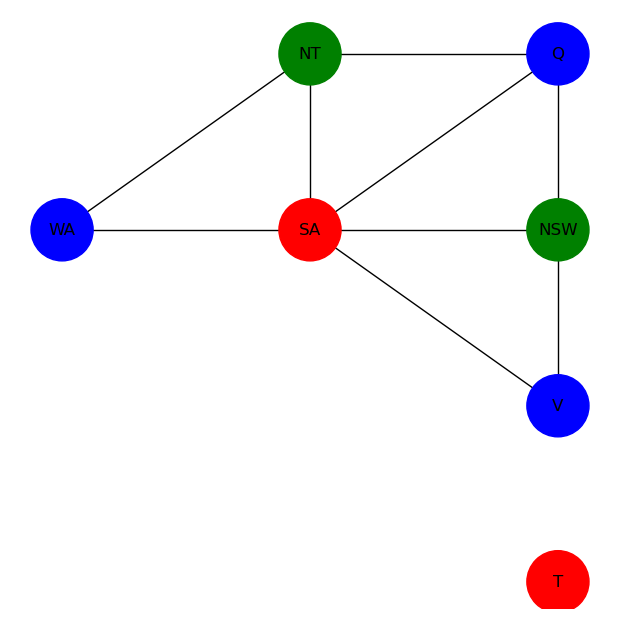

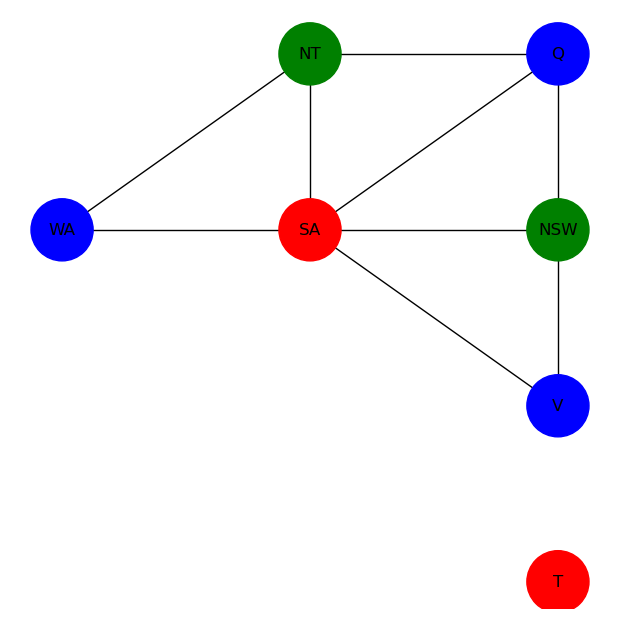

Final Solution:
{'SA': 'Red', 'NT': 'Green', 'Q': 'Blue', 'NSW': 'Green', 'WA': 'Blue', 'V': 'Blue', 'T': 'Red'}


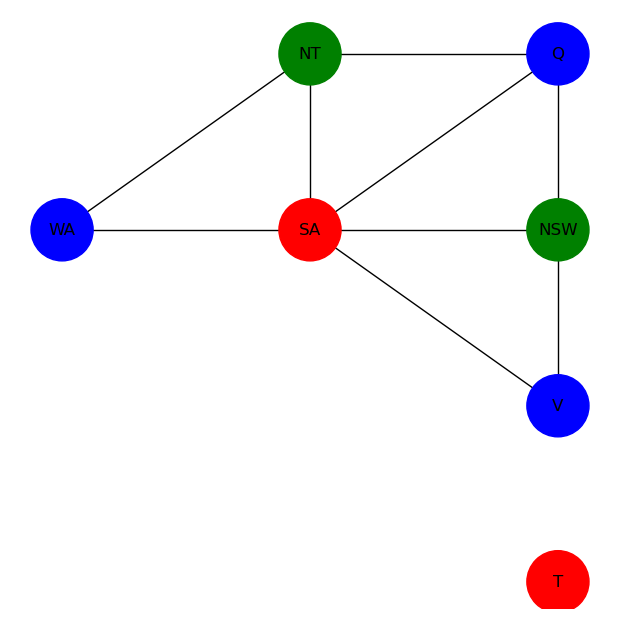

In [4]:
import networkx as nx
import matplotlib.pyplot as plt
import time
import copy

class CSP:
    def __init__(self, variables, domains, neighbors):
        self.variables = variables
        self.domains = domains
        self.neighbors = neighbors
        self.steps = []

    def is_consistent(self, var, value, assignment):
        for neighbor in self.neighbors[var]:
            if neighbor in assignment and assignment[neighbor] == value:
                return False
        return True

    def forward_check(self, var, value, domains, assignment):
        new_domains = copy.deepcopy(domains)
        for neighbor in self.neighbors[var]:
            if neighbor not in assignment:
                if value in new_domains[neighbor]:
                    new_domains[neighbor].remove(value)
                if not new_domains[neighbor]:
                    return None
        return new_domains

    def select_unassigned_variable(self, assignment, domains):
        unassigned = [v for v in self.variables if v not in assignment]

        mrv = sorted(unassigned, key=lambda var: len(domains[var]))
        min_val = len(domains[mrv[0]])

        candidates = [v for v in mrv if len(domains[v]) == min_val]

        if len(candidates) == 1:
            return candidates[0]

        return max(candidates, key=lambda var: len(self.neighbors[var]))

    def backtrack(self, assignment, domains):
        if len(assignment) == len(self.variables):
            self.steps.append(assignment.copy())
            return assignment

        var = self.select_unassigned_variable(assignment, domains)

        for value in domains[var]:
            if self.is_consistent(var, value, assignment):
                new_assignment = assignment.copy()
                new_assignment[var] = value

                self.steps.append(new_assignment.copy())

                new_domains = self.forward_check(var, value, domains, new_assignment)

                if new_domains is not None:
                    result = self.backtrack(new_assignment, new_domains)
                    if result:
                        return result

        return None


variables = ['WA', 'NT', 'Q', 'SA', 'NSW', 'V', 'T']

domains = {v: ['Red', 'Green', 'Blue'] for v in variables}

neighbors = {
    'WA': ['NT', 'SA'],
    'NT': ['WA', 'SA', 'Q'],
    'Q': ['NT', 'SA', 'NSW'],
    'SA': ['WA', 'NT', 'Q', 'NSW', 'V'],
    'NSW': ['Q', 'SA', 'V'],
    'V': ['SA', 'NSW'],
    'T': []
}


csp = CSP(variables, domains, neighbors)
solution = csp.backtrack({}, domains)


G = nx.Graph()
for var in variables:
    G.add_node(var)

for var in neighbors:
    for n in neighbors[var]:
        G.add_edge(var, n)


color_map = {
    'Red': 'red',
    'Green': 'green',
    'Blue': 'blue'
}


pos = {
    'WA': (0, 2),
    'NT': (1, 3),
    'SA': (1, 2),
    'Q': (2, 3),
    'NSW': (2, 2),
    'V': (2, 1),
    'T': (2, 0)
}


def draw_graph(assignment):
    plt.figure(figsize=(6,6))
    colors = []
    for node in G.nodes():
        if node in assignment:
            colors.append(color_map[assignment[node]])
        else:
            colors.append('lightgray')

    nx.draw(G, pos, with_labels=True, node_color=colors, node_size=2000, font_size=12)
    plt.show()


print("Animating CSP solving...\n")

for step in csp.steps:
    draw_graph(step)
    time.sleep(0.5)


print("Final Solution:")
print(solution)

draw_graph(solution)